# Synthetic marker-memory task: `ParaLSTM` learning demo

This notebook is a **learning-focused** demo for the paper-faithful `ParaLSTM`.

The pixel-wise MNIST notebook is useful as a long-sequence runtime/API stress test, but it is not a good learning sanity check when even `torch.nn.LSTM` does not learn. Here we use a controlled synthetic task where a recurrent model should learn quickly.

## Task

Each sequence has length $T$. One random position $m$ is marked. At that position, the model receives a scalar value $v_m$. The label is

$$
y = \mathbf{1}{v_m > 0}.
$$

The model must:

1. detect the marker,
2. store the marked value,
3. keep it until the final hidden state,
4. classify the sign.

We compare:

```text
ParaLSTM sequential
ParaLSTM block-DEER
torch.nn.LSTM
```

The main algorithmic comparison is **ParaLSTM sequential vs ParaLSTM block-DEER**, because both use the same ParaLSTM cell.

In [1]:
from pathlib import Path
import sys
import time
import gc
from dataclasses import dataclass, asdict

import torch
from torch import nn
import matplotlib.pyplot as plt

try:
    import pandas as pd
except ImportError:
    pd = None


def find_project_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "src" / "pararnn").exists():
            return candidate
    raise RuntimeError(
        "Could not find project root. Run this notebook from the repo root "
        "or from the notebooks/ directory."
    )


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.pararnn import ParaLSTM, ParaLSTMCell

print("Project root:", PROJECT_ROOT)
print("Torch version:", torch.__version__)

Project root: /home/cpt/Documents/Github/Parallel-RNN
Torch version: 2.12.0+cu130


In [2]:
@dataclass
class Config:
    seed: int = 42

    # Synthetic task shape.
    sequence_length: int = 128
    input_size: int = 3
    num_classes: int = 2

    # Model size.
    hidden_size: int = 64

    # ParaLSTM block-DEER settings.
    paralstm_num_iters: int = 3
    paralstm_recurrent_init_scale: float = 0.05
    paralstm_input_init_scale: float = 1.0
    paralstm_forget_bias_init_value: float = 1.0

    # Training settings.
    train_samples: int = 8_192
    test_samples: int = 2_048
    batch_size: int = 128
    epochs: int = 8
    learning_rate: float = 3e-3
    weight_decay: float = 1e-4
    grad_clip: float = 1.0

    dtype: torch.dtype = torch.float32


cfg = Config()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Keep CPU runs small. GPU is recommended for the block-DEER model.
if device.type == "cpu":
    cfg.train_samples = 2_048
    cfg.test_samples = 512
    cfg.batch_size = 64
    cfg.epochs = 5

torch.manual_seed(cfg.seed)

if device.type == "cuda":
    torch.set_float32_matmul_precision("high")
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU. This will be slower.")

print(cfg)

GPU: NVIDIA GeForce RTX 3070 Laptop GPU
Config(seed=42, sequence_length=128, input_size=3, num_classes=2, hidden_size=64, paralstm_num_iters=3, paralstm_recurrent_init_scale=0.05, paralstm_input_init_scale=1.0, paralstm_forget_bias_init_value=1.0, train_samples=8192, test_samples=2048, batch_size=128, epochs=8, learning_rate=0.003, weight_decay=0.0001, grad_clip=1.0, dtype=torch.float32)


## Dataset

Input channels:

```text
x[..., 0] = small background noise
x[..., 1] = marker bit; exactly one time step has marker = 1
x[..., 2] = marked value; zero everywhere except the marked time step
```

The label is the sign of the marked value.

In [3]:
def make_marker_memory_dataset(
    num_samples: int,
    sequence_length: int,
    *,
    seed: int,
    dtype: torch.dtype,
    device: torch.device,
):
    gen = torch.Generator(device="cpu").manual_seed(seed)

    marker_index = torch.randint(
        low=0,
        high=sequence_length,
        size=(num_samples,),
        generator=gen,
    )

    sign = 2.0 * torch.randint(
        low=0,
        high=2,
        size=(num_samples,),
        generator=gen,
        dtype=torch.float32,
    ) - 1.0

    magnitude = 0.5 + torch.rand(num_samples, generator=gen)
    marked_value = sign * magnitude

    x = torch.zeros(num_samples, sequence_length, 3, dtype=dtype)

    # Small distractor/background noise.
    x[:, :, 0] = 0.05 * torch.randn(
        num_samples,
        sequence_length,
        generator=gen,
        dtype=dtype,
    )

    rows = torch.arange(num_samples)
    x[rows, marker_index, 1] = 1.0
    x[rows, marker_index, 2] = marked_value.to(dtype)

    y = (marked_value > 0.0).long()

    return (
        x.to(device=device),
        y.to(device=device),
        marker_index,
        marked_value,
    )


X_train, y_train, marker_train, value_train = make_marker_memory_dataset(
    cfg.train_samples,
    cfg.sequence_length,
    seed=cfg.seed,
    dtype=cfg.dtype,
    device=device,
)
X_test, y_test, marker_test, value_test = make_marker_memory_dataset(
    cfg.test_samples,
    cfg.sequence_length,
    seed=cfg.seed + 10_000,
    dtype=cfg.dtype,
    device=device,
)

print("X_train:", tuple(X_train.shape))
print("y_train:", tuple(y_train.shape))
print("class balance:", torch.bincount(y_train.detach().cpu()))
print("example marker index:", int(marker_train[0]))
print("example marked value:", float(value_train[0]))
print("example label:", int(y_train[0]))

X_train: (8192, 128, 3)
y_train: (8192,)
class balance: tensor([4142, 4050])
example marker index: 102
example marked value: -1.2621939182281494
example label: 0


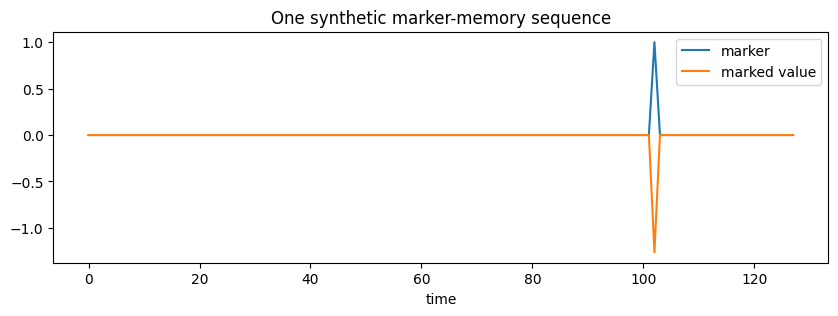

In [4]:
# Visualize one sample.
sample_idx = 0
x_sample = X_train[sample_idx].detach().cpu()

plt.figure(figsize=(10, 3))
plt.plot(x_sample[:, 1], label="marker")
plt.plot(x_sample[:, 2], label="marked value")
plt.title("One synthetic marker-memory sequence")
plt.xlabel("time")
plt.legend()
plt.show()

## Models

`ParaLSTM sequential` and `ParaLSTM block-DEER` use the same ParaLSTM recurrence family. We initialize them identically by copying the same `state_dict`.

`torch.nn.LSTM` is included only to confirm that the synthetic task is learnable by a standard LSTM too.

In [5]:
class MarkerMemoryParaLSTMClassifier(nn.Module):
    def __init__(self, cfg: Config, *, mode: str):
        super().__init__()

        self.rnn = ParaLSTM(
            input_size=cfg.input_size,
            hidden_size=cfg.hidden_size,
            batch_first=True,
            mode=mode,
            backend="autograd",
            scan_backend="torch",
            num_iters=cfg.paralstm_num_iters,
            tol=None,
            strict_tol=False,
            dtype=cfg.dtype,
            recurrent_init_scale=cfg.paralstm_recurrent_init_scale,
            input_init_scale=cfg.paralstm_input_init_scale,
            forget_bias_init_value=cfg.paralstm_forget_bias_init_value,
        )
        self.head = nn.Linear(cfg.hidden_size, cfg.num_classes, dtype=cfg.dtype)

    def forward(self, x):
        _, (h_n, _) = self.rnn(x)
        return self.head(h_n[-1])


class MarkerMemoryTorchLSTMClassifier(nn.Module):
    def __init__(self, cfg: Config):
        super().__init__()

        self.rnn = nn.LSTM(
            input_size=cfg.input_size,
            hidden_size=cfg.hidden_size,
            batch_first=True,
        )
        self.head = nn.Linear(cfg.hidden_size, cfg.num_classes)

    def forward(self, x):
        _, (h_n, _) = self.rnn(x)
        return self.head(h_n[-1])


def make_models(cfg: Config):
    torch.manual_seed(cfg.seed)

    paralstm_seq = MarkerMemoryParaLSTMClassifier(cfg, mode="sequential").to(device)
    paralstm_deer = MarkerMemoryParaLSTMClassifier(cfg, mode="deer").to(device)
    paralstm_deer.load_state_dict(paralstm_seq.state_dict())

    torch.manual_seed(cfg.seed)
    torch_lstm = MarkerMemoryTorchLSTMClassifier(cfg).to(device=device, dtype=cfg.dtype)

    return {
        "ParaLSTM sequential": paralstm_seq,
        "ParaLSTM block-DEER": paralstm_deer,
        "Torch LSTM": torch_lstm,
    }


models = make_models(cfg)

# First-batch sanity check.
xb = X_train[: cfg.batch_size]
yb = y_train[: cfg.batch_size]
criterion = nn.CrossEntropyLoss()

for name, model in models.items():
    model.zero_grad(set_to_none=True)
    logits = model(xb)
    loss = criterion(logits, yb)
    loss.backward()

    grad_norm = 0.0
    for p in model.parameters():
        if p.grad is not None:
            grad_norm += float(p.grad.detach().norm().cpu())

    print(name)
    print("  logits:", tuple(logits.shape))
    print("  loss:", float(loss.detach().cpu()))
    print("  grad norm:", grad_norm)

ParaLSTM sequential
  logits: (128, 2)
  loss: 0.6982059478759766
  grad norm: 0.12721312717167166
ParaLSTM block-DEER
  logits: (128, 2)
  loss: 0.6982059478759766
  grad norm: 0.12721310774668382
Torch LSTM
  logits: (128, 2)
  loss: 0.6906325817108154
  grad norm: 0.08842009131330997


## Training utilities

In [6]:
def cuda_sync():
    if device.type == "cuda":
        torch.cuda.synchronize()


def reset_peak_memory():
    if device.type == "cuda":
        torch.cuda.reset_peak_memory_stats(device)


def peak_memory_mb() -> float:
    if device.type != "cuda":
        return 0.0
    return torch.cuda.max_memory_allocated(device) / (1024.0 * 1024.0)


def clear_memory():
    gc.collect()
    if device.type == "cuda":
        torch.cuda.empty_cache()
        torch.cuda.synchronize()


@torch.no_grad()
def evaluate(model, X, y, batch_size: int):
    model.eval()

    criterion = nn.CrossEntropyLoss(reduction="sum")
    total_loss = 0.0
    total_correct = 0
    total = 0

    for start in range(0, X.shape[0], batch_size):
        end = min(start + batch_size, X.shape[0])
        xb = X[start:end]
        yb = y[start:end]

        logits = model(xb)
        loss = criterion(logits, yb)

        total_loss += float(loss.detach().cpu())
        total_correct += int((logits.argmax(dim=-1) == yb).sum().detach().cpu())
        total += yb.numel()

    return total_loss / total, total_correct / total


def make_epoch_permutations(num_samples: int, epochs: int, seed: int):
    gen = torch.Generator(device="cpu").manual_seed(seed)
    return [torch.randperm(num_samples, generator=gen) for _ in range(epochs)]


def train_one_model(name, model, cfg, X_train, y_train, X_test, y_test, permutations):
    clear_memory()
    reset_peak_memory()

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=cfg.learning_rate,
        weight_decay=cfg.weight_decay,
    )

    history = []
    total_train_seconds = 0.0

    print(f"\n=== {name} ===")

    for epoch in range(cfg.epochs):
        model.train()
        cuda_sync()
        start_time = time.perf_counter()

        total_loss = 0.0
        total_correct = 0
        total = 0

        for idx_cpu in permutations[epoch].split(cfg.batch_size):
            idx = idx_cpu.to(device=device)
            xb = X_train.index_select(0, idx)
            yb = y_train.index_select(0, idx)

            optimizer.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()

            if cfg.grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)

            optimizer.step()

            with torch.no_grad():
                total_loss += float(loss.detach().cpu()) * yb.numel()
                total_correct += int((logits.argmax(dim=-1) == yb).sum().detach().cpu())
                total += yb.numel()

        cuda_sync()
        epoch_seconds = time.perf_counter() - start_time
        total_train_seconds += epoch_seconds

        train_loss = total_loss / total
        train_acc = total_correct / total
        test_loss, test_acc = evaluate(model, X_test, y_test, cfg.batch_size)

        record = {
            "model": name,
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "test_loss": test_loss,
            "test_acc": test_acc,
            "epoch_seconds": epoch_seconds,
        }
        history.append(record)

        print(
            f"epoch={epoch+1:02d} "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
            f"test_loss={test_loss:.4f} test_acc={test_acc:.4f} "
            f"seconds={epoch_seconds:.2f}"
        )

    peak = peak_memory_mb()

    return {
        "name": name,
        "history": history,
        "train_seconds": total_train_seconds,
        "peak_memory_mb": peak,
        "model": model,
    }

## Train all models

In [7]:
# Rebuild fresh models after the sanity-check backward pass.
models = make_models(cfg)

# Same mini-batch order for all models.
permutations = make_epoch_permutations(
    num_samples=cfg.train_samples,
    epochs=cfg.epochs,
    seed=cfg.seed + 123,
)

results = []

for name, model in models.items():
    result = train_one_model(
        name=name,
        model=model,
        cfg=cfg,
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        y_test=y_test,
        permutations=permutations,
    )
    results.append(result)

print("\nDone.")


=== ParaLSTM sequential ===
epoch=01 train_loss=0.6873 train_acc=0.5382 test_loss=0.6774 test_acc=0.5483 seconds=11.32
epoch=02 train_loss=0.6543 train_acc=0.5767 test_loss=0.6286 test_acc=0.5752 seconds=11.67
epoch=03 train_loss=0.4850 train_acc=0.7639 test_loss=0.1733 test_acc=0.9868 seconds=12.52
epoch=04 train_loss=0.0274 train_acc=0.9990 test_loss=0.0013 test_acc=1.0000 seconds=9.77
epoch=05 train_loss=0.0009 train_acc=1.0000 test_loss=0.0006 test_acc=1.0000 seconds=9.64
epoch=06 train_loss=0.0005 train_acc=1.0000 test_loss=0.0004 test_acc=1.0000 seconds=9.59
epoch=07 train_loss=0.0003 train_acc=1.0000 test_loss=0.0002 test_acc=1.0000 seconds=9.54
epoch=08 train_loss=0.0002 train_acc=1.0000 test_loss=0.0002 test_acc=1.0000 seconds=9.48

=== ParaLSTM block-DEER ===
epoch=01 train_loss=0.6873 train_acc=0.5382 test_loss=0.6774 test_acc=0.5483 seconds=8.39
epoch=02 train_loss=0.6543 train_acc=0.5767 test_loss=0.6286 test_acc=0.5752 seconds=7.32
epoch=03 train_loss=0.4851 train_acc=0.

## Results

In [8]:
summary_rows = []
all_history = []

for result in results:
    final = result["history"][-1]
    summary_rows.append(
        {
            "model": result["name"],
            "final_test_acc": final["test_acc"],
            "final_test_loss": final["test_loss"],
            "train_seconds": result["train_seconds"],
            "peak_memory_mb": result["peak_memory_mb"],
        }
    )
    all_history.extend(result["history"])

if pd is not None:
    summary_df = pd.DataFrame(summary_rows)
    history_df = pd.DataFrame(all_history)
    display(summary_df)
else:
    summary_df = summary_rows
    history_df = all_history
    for row in summary_rows:
        print(row)

# Useful speed ratio when both are present.
by_name = {row["model"]: row for row in summary_rows}
if "ParaLSTM sequential" in by_name and "ParaLSTM block-DEER" in by_name:
    ratio = by_name["ParaLSTM sequential"]["train_seconds"] / by_name["ParaLSTM block-DEER"]["train_seconds"]
    print(f"ParaLSTM block-DEER speedup over ParaLSTM sequential: {ratio:.2f}x")

if "Torch LSTM" in by_name and by_name["Torch LSTM"]["final_test_acc"] < 0.80:
    print(
        "\nWARNING: Torch LSTM did not learn strongly. "
        "Try increasing epochs or lowering sequence_length to 64."
    )

,model,final_test_acc,final_test_loss,train_seconds,peak_memory_mb
0,ParaLSTM sequential,1.000000,0.000172,83.521636,72.783203
1,ParaLSTM block-DEER,1.000000,0.000163,62.565357,827.194824
2,Torch LSTM,0.802246,0.534350,1.463673,157.831055


ParaLSTM block-DEER speedup over ParaLSTM sequential: 1.33x


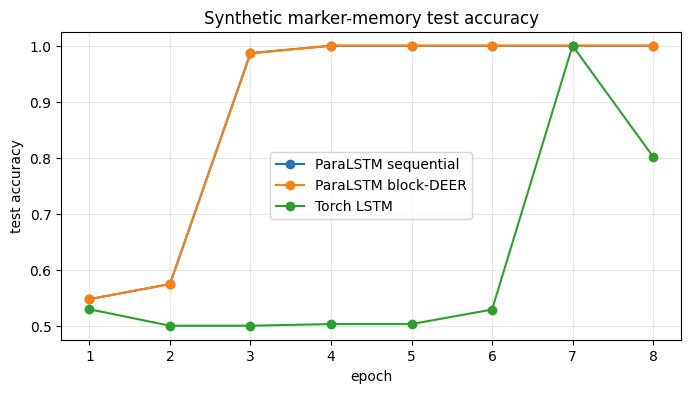

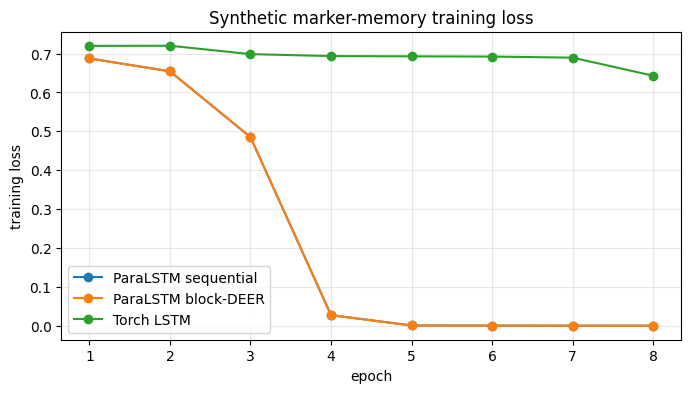

In [9]:
if pd is not None:
    plt.figure(figsize=(8, 4))
    for name in history_df["model"].unique():
        sub = history_df[history_df["model"] == name]
        plt.plot(sub["epoch"], sub["test_acc"], marker="o", label=name)

    plt.xlabel("epoch")
    plt.ylabel("test accuracy")
    plt.title("Synthetic marker-memory test accuracy")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure(figsize=(8, 4))
    for name in history_df["model"].unique():
        sub = history_df[history_df["model"] == name]
        plt.plot(sub["epoch"], sub["train_loss"], marker="o", label=name)

    plt.xlabel("epoch")
    plt.ylabel("training loss")
    plt.title("Synthetic marker-memory training loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## Inspect DEER diagnostics

After training, the block-DEER model should report the paper-faithful LSTM variant:

```text
cell_variant = cifg_peephole_diag
```

and a small final residual merit.

In [10]:
deer_model = results[1]["model"]
info = deer_model.rnn.last_deer_infos[0]
info

{'num_iters': 3,
 'initial_merit': tensor(602.7767, device='cuda:0'),
 'final_merit': tensor(0.4909, device='cuda:0'),
 'last_update_error': tensor(0.2831, device='cuda:0'),
 'tol': None,
 'effective_tol': 0.0001,
 'strict_tol': False,
 'stopping_criterion': 'update',
 'scan_backend': 'torch_block2_associative_scan',
 'quasi': True,
 'batched': True,
 'batch_size': 128,
 'jacobian_backend': 'explicit_block2',
 'linearization_backend': 'custom_block2',
 'backward_backend': 'autograd',
 'cell_variant': 'cifg_peephole_diag'}

## Direct `ParaLSTMCell` example

In [11]:
cell = ParaLSTMCell(
    input_size=cfg.input_size,
    hidden_size=cfg.hidden_size,
    dtype=cfg.dtype,
).to(device)

x_t = torch.randn(4, cfg.input_size, device=device, dtype=cfg.dtype)
h = torch.zeros(4, cfg.hidden_size, device=device, dtype=cfg.dtype)
c = torch.zeros(4, cfg.hidden_size, device=device, dtype=cfg.dtype)

h_next, c_next = cell(x_t, (h, c))

print("h_next:", tuple(h_next.shape))
print("c_next:", tuple(c_next.shape))

h_next: (4, 64)
c_next: (4, 64)


## Interpretation

This notebook is successful if:

```text
Torch LSTM learns the task.
ParaLSTM sequential learns the task.
ParaLSTM block-DEER learns similarly to ParaLSTM sequential.
````

The important algorithmic conclusion is not that ParaLSTM beats cuDNN LSTM. The fair comparison is:

$$
\text{ParaLSTM sequential}
\quad \text{vs} \quad
\text{ParaLSTM block-DEER}
$$

Both use the same ParaLSTM recurrence family; the block-DEER version replaces the ordinary sequential scan through time with a parallel Newton/block-scan solve. Torch LSTM is included only as a learnability baseline, not as the primary speed comparison.